# AMEX Default Prediction

Interview-ready client behavior modeling project for predicting default risk on the American Express Kaggle dataset.

## Workflow
1. Data loading
2. EDA
3. Preprocessing and feature engineering
4. Baseline modeling (Logistic Regression + Gradient Boosting)
5. Evaluation (AUC, PR-AUC, decile lift)
6. Explainability and segment insights

## 1. Setup
- Primary data source: Google Drive folder `'/content/drive/MyDrive/amex_data_parquet'`.
- Required files:
  - `train_data.parquet`
  - `train_labels.csv`
- Optional one-time helper block in the next cell downloads missing `train_labels.csv`.


In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, List, Tuple
import os
import shutil
import subprocess
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
RANDOM_STATE = 42
MAX_TREND_COLS = 15                # down from 40
TEST_MAX_TREND_COLS = 8
SAMPLE_FRAC = 0.3                  # down from 1
USE_GOOGLE_DRIVE_DATA = True
GOOGLE_DRIVE_DIR = Path('/content/drive/MyDrive/amex_data_parquet')
LOCAL_DATA_DIR = Path('../data/raw/amex-default-prediction')
KAGGLEHUB_DATASET = 'ruchi798/parquet-files-amexdefault-prediction'
KAGGLE_COMPETITION = 'amex-default-prediction'
USE_GPU_FOR_BOOSTING = False
USE_SPARK_FEATURES = False
SPARK_SHUFFLE_PARTITIONS = "120"   # not 400
IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in globals() else False
if IN_COLAB and USE_GOOGLE_DRIVE_DATA:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print(f'Drive mount skipped/failed: {e}')
def detect_gpu_available() -> bool:
    if not USE_GPU_FOR_BOOSTING:
        return False
    try:
        run = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True)
        return run.returncode == 0 and bool(run.stdout.strip())
    except Exception:
        return False
GPU_AVAILABLE = detect_gpu_available()
try:
    from pyspark.sql import SparkSession
    HAS_SPARK = True
except Exception:
    HAS_SPARK = False
spark = None
if HAS_SPARK and USE_SPARK_FEATURES:
    try:
        spark = (
            SparkSession.builder
            .appName('amex-default-prediction')
            .config('spark.sql.shuffle.partitions', SPARK_SHUFFLE_PARTITIONS)
            .config('spark.driver.memory', '16g')
            .getOrCreate()
        )
    except Exception as e:
        print(f'Spark init failed, fallback to pandas features: {e}')
        spark = None
try:
    import kagglehub
    HAS_KAGGLEHUB = True
except Exception:
    HAS_KAGGLEHUB = False
try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
print({
    'in_colab': IN_COLAB,
    'gpu_available': GPU_AVAILABLE,
    'spark_enabled': spark is not None,
    'kagglehub': HAS_KAGGLEHUB,
    'lightgbm': HAS_LGBM,
    'xgboost': HAS_XGB,
    'shap': HAS_SHAP
})



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'in_colab': True, 'gpu_available': False, 'spark_enabled': False, 'kagglehub': True, 'lightgbm': True, 'xgboost': True, 'shap': True}


## 2. Data Loading

In [2]:
# Minimal Colab + Google Drive data loading
# Keep this block as-is for the AMEX project.

if False:

    # 0) (if needed) set Kaggle creds
    from google.colab import files
    files.upload()  # upload kaggle.json

    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json

    # 1) make target folder
    !mkdir -p /content/drive/MyDrive/amex_data_parquet

    # 2) download test parquet dataset via kagglehub
    !pip -q install -U kagglehub
    import kagglehub, shutil
    from pathlib import Path

    src = Path(kagglehub.dataset_download("ruchi798/parquet-files-amexdefault-prediction"))
    dst = Path("/content/drive/MyDrive/amex_data_parquet")

    for f in ["test_data.parquet", "train_data.parquet", "train_labels.csv"]:
        s = src / f
        if s.exists():
            shutil.copy2(s, dst / f)

    print("Done:", [p.name for p in dst.glob("*.parquet")])

from pathlib import Path
import pandas as pd

base = Path('/content/drive/MyDrive/amex_data_parquet')
labels_path = base / 'train_labels.csv'

if False:
    train = pd.read_parquet(base / 'train_data.parquet')
else:
    train = pd.read_parquet('/content/drive/MyDrive/amex_data_parquet/train_data.parquet')

labels = pd.read_csv(labels_path)
train['S_2'] = pd.to_datetime(train['S_2'])

raw_df = train
labels_df = labels

print(raw_df.shape, labels_df.shape)
raw_df.head(3)



(5531451, 190) (978, 2)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,B_20,D_68,S_12,R_6,S_13,B_21,D_69,B_22,D_70,D_71,D_72,S_15,B_23,D_73,P_4,D_74,D_75,D_76,B_24,R_7,D_77,B_25,B_26,D_78,D_79,R_8,R_9,S_16,D_80,R_10,R_11,B_27,D_81,D_82,S_17,R_12,B_28,R_13,D_83,R_14,R_15,D_84,R_16,B_29,B_30,S_18,D_86,D_87,R_17,R_18,D_88,B_31,S_19,R_19,B_32,S_20,R_20,R_21,B_33,D_89,R_22,R_23,D_91,D_92,D_93,D_94,R_24,R_25,D_96,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,NaN,NaN,0.000630,0.080986,0.708906,0.170600,0.006204,0.358587,0.525351,0.255736,NaN,0.063902,0.059416,0.006466,0.148698,1.335856,0.008207,0.001423,0.207334,0.736463,0.096219,NaN,0.023381,0.002768,0.008322,1.001519,0.008298,0.161345,0.148266,0.922998,0.354596,0.152025,0.118075,0.001882,0.158612,0.065728,0.018385,0.063646,0.199617,0.308233,0.016361,0.401619,0.091071,CR,O,0.007126,0.007665,NaN,0.652984,0.008520,NaN,0.004730,6.0,0.272008,0.008363,0.515222,0.002644,0.009013,0.004808,0.008342,0.119403,0.004802,0.108271,0.050882,NaN,0.007554,0.080422,0.069067,NaN,0.004327,0.007562,NaN,0.007729,0.000272,0.001576,0.004239,0.001434,NaN,0.002271,0.004061,0.007121,0.002456,0.002310,0.003532,0.506612,0.008033,1.009825,0.084683,0.003820,0.007043,0.000438,0.006452,0.000830,0.005055,NaN,0.0,0.005720,0.007084,NaN,0.000198,0.008907,NaN,1,0.002537,0.005177,0.006626,0.009705,0.007782,0.002450,1.001101,0.002665,0.007479,0.006893,1.503673,1.006133,0.003569,0.008871,0.003950,0.003647,0.004950,0.894090,0.135561,0.911191,0.974539,0.001243,0.766688,1.008691,1.004587,0.893734,NaN,0.670041,0.009968,0.004572,NaN,1.008949,2.0,NaN,0.004326,NaN,NaN,NaN,1.007336,0.210060,0.676922,0.007871,1.0,0.238250,0.0,4.0,0.232120,0.236266,0.0,0.702280,0.434345,0.003057,0.686516,0.008740,1.0,1.003319,1.007819,1.000080,0.006805,NaN,0.002052,0.005972,NaN,0.004345,0.001535,NaN,NaN,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,NaN,NaN,0.002526,0.069419,0.712795,0.113239,0.006206,0.353630,0.521311,0.223329,NaN,0.065261,0.057744,0.001614,0.149723,1.339794,0.008373,0.001984,0.202778,0.720886,0.099804,NaN,0.030599,0.002749,0.002482,1.009033,0.005136,0.140951,0.143530,0.919414,0.326757,0.156201,0.118737,0.001610,0.148459,0.093935,0.013035,0.065501,0.151387,0.265026,0.017688,0.406326,0.086805,CR,O,0.002413,0.007148,NaN,0.647093,0.002238,NaN,0.003879,6.0,0.188970,0.004030,0.509048,0.004193,0.007842,0.001283,0.006524,0.140611,0.000094,0.101018,0.040469,NaN,0.004832,0.081413,0.074166,NaN,0.004203,0.005304,NaN,0.001864,0.000979,0.009896,0.007597,0.000509,NaN,0.009810,0.000127,0.005966,0.000395,0.001327,0.007773,0.500855,0.000760,1.009461,0.081843,0.000347,0.007789,0.004311,0.002332,0.009469,0.003753,NaN,0.0,0.007584,0.006677,NaN,0.001142,0.005907,NaN,1,0.008427,0.008979,0.001854,0.009924,0.005987,0.002247,1.006779,0.002508,0.006827,0.002837,1.503577,1.005791,0.000571,0.000391,0.008351,0.008850,0.003180,0.902135,0.136333,0.919876,0.975624,0.004561,0.786007,1.000084,1.004118,0.906841,NaN,0.668647,0.003921,0.004654,NaN,1.003205,2.0,NaN,0.008707,NaN,NaN,NaN,1.007653,0.184093,0.822281,0.003444,1.0,0.247217,0.0,4.0,0.243532,0.241885,0.0,0.707017,0.430501,0.001306,0.686414,0.000755,1.0,1.008394,1.004333,1.008344,0.004407,NaN,0.001034,0.004838,NaN,0.

## 3. EDA (Quick but Decision-Oriented)

In [3]:
print('Raw columns:', len(raw_df.columns))
print('Unique customers:', raw_df['customer_ID'].nunique())
print('Date range:', raw_df['S_2'].min(), 'to', raw_df['S_2'].max())

labels_df['target'].value_counts(normalize=True).rename('target_rate')

Raw columns: 190
Unique customers: 458913
Date range: 2017-03-01 00:00:00 to 2018-03-31 00:00:00


,target_rate
target,
0.0,0.734903
1.0,0.265097


In [4]:
# Missingness profile
missing_rate = raw_df.isna().mean().sort_values(ascending=False)
missing_rate.head(15)

,0
D_87,0.999301
D_88,0.998915
D_108,0.994768
D_110,0.994335
D_111,0.994335
B_39,0.993920
D_73,0.989902
B_42,0.987078
D_135,0.964801
D_134,0.964801


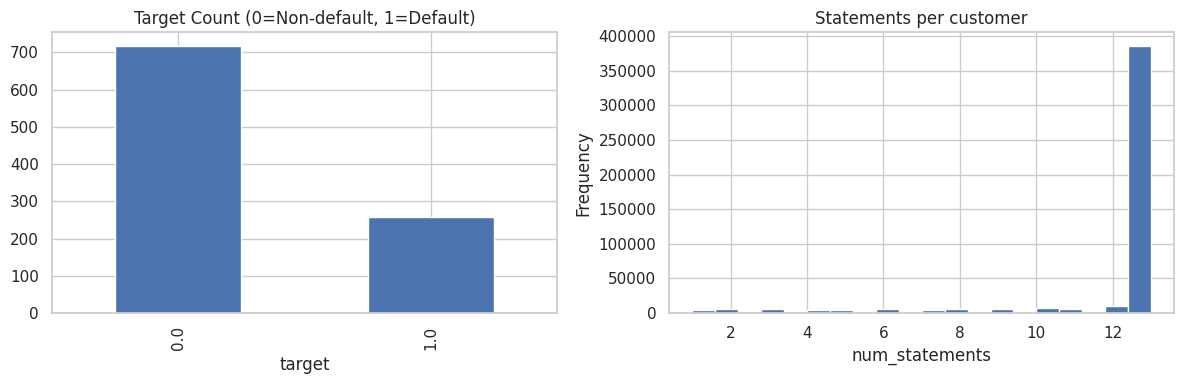

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

labels_df['target'].value_counts().sort_index().plot(kind='bar', ax=ax[0], title='Target Count (0=Non-default, 1=Default)')
ax[0].set_xlabel('target')

obs_per_customer = raw_df.groupby('customer_ID').size()
obs_per_customer.plot(kind='hist', bins=20, ax=ax[1], title='Statements per customer')
ax[1].set_xlabel('num_statements')

plt.tight_layout()

## 4. Time-Aware Split and Leakage-Safe Feature Engineering

We aggregate per customer using only available historical statements and split by each customer's *latest statement date*.

In [6]:
def safe_slope(values: np.ndarray) -> float:
    mask = ~np.isnan(values)
    if mask.sum() < 2:
        return np.nan
    y = values[mask]
    x = np.arange(len(values))[mask]
    x_centered = x - x.mean()
    denom = np.sum(x_centered ** 2)
    if denom == 0:
        return 0.0
    return np.sum(x_centered * (y - y.mean())) / denom

def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """ Reduce memory usage of a DataFrame by downcasting numeric types. """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype
        if str(col_type).startswith('float'):
            df[col] = df[col].astype(np.float32)
        elif str(col_type).startswith('int'):
            # find smallest int type that fits
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {(100 * (start_mem - end_mem) / start_mem):.2f}%')
    return df

def make_customer_features_pandas(df: pd.DataFrame, max_trend_cols: int = 40) -> pd.DataFrame:
    df = df.sort_values(['customer_ID', 'S_2']).copy()
    df = reduce_mem_usage(df) # Apply memory reduction

    id_cols = ['customer_ID', 'S_2']
    feature_cols = [c for c in df.columns if c not in id_cols]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
    trend_cols = numeric_cols[:max_trend_cols]

    grouped = df.groupby('customer_ID', sort=False)
    pieces = []

    num_agg = grouped[numeric_cols].agg(['last', 'mean', 'std', 'min', 'max'])
    num_agg.columns = [f'{col}_{stat}' for col, stat in num_agg.columns]
    pieces.append(num_agg)

    group_size = grouped.size().rename('n_rows')
    num_count = grouped[numeric_cols].count()
    miss = 1.0 - num_count.div(group_size, axis=0)
    miss.columns = [f'{c}_missing_rate' for c in miss.columns]
    pieces.append(miss)

    trend_frames = []
    for c in trend_cols:
        slopes = grouped[c].apply(lambda s: safe_slope(s.values.astype(float)))
        trend_frames.append(slopes.rename(f'{c}_trend'))
    if trend_frames:
        pieces.append(pd.concat(trend_frames, axis=1))

    max_date = df['S_2'].max()
    time_feats = grouped['S_2'].agg(last_statement_date='max', first_date='min', n_statements='count')
    time_feats['recency_days'] = (max_date - time_feats['last_statement_date']).dt.days
    time_feats['history_days'] = (time_feats['last_statement_date'] - time_feats['first_date']).dt.days
    pieces.append(time_feats.drop(columns=['first_date']))

    known_cat_cols = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
    cat_cols = [c for c in known_cat_cols if c in df.columns]
    if cat_cols:
        cat_last = grouped[cat_cols].last().add_suffix('_last_cat')
        cat_nunique = grouped[cat_cols].nunique(dropna=True).add_suffix('_nunique_cat')
        pieces.extend([cat_last, cat_nunique])

    return pd.concat(pieces, axis=1).reset_index()


def make_customer_features(df: pd.DataFrame, max_trend_cols: int = 40) -> pd.DataFrame:
    print('Using pandas feature engineering...')
    return make_customer_features_pandas(df, max_trend_cols=max_trend_cols)


RETRAIN_FEATURES = False
N_CHUNKS_TRAIN = 24
N_CHUNKS_TEST = 32
TEST_MAX_TREND_COLS = 10

feature_cache_dir = Path('/content/drive/MyDrive/amex_data_parquet/features')
feature_cache_dir.mkdir(parents=True, exist_ok=True)

train_feature_path = feature_cache_dir / 'customer_features_train.parquet'
test_feature_path = feature_cache_dir / 'customer_features_test.parquet'
train_chunk_dir = feature_cache_dir / 'train_chunks'
test_chunk_dir = feature_cache_dir / 'test_chunks'


def stable_bucket_ids(customer_series: pd.Series, n_chunks: int) -> pd.Series:
    h = pd.util.hash_pandas_object(customer_series.astype('string'), index=False).astype('uint64')
    return (h % np.uint64(n_chunks)).astype('int64')


def build_feature_chunks_to_disk(
    df: pd.DataFrame,
    out_dir: Path,
    n_chunks: int,
    max_trend_cols: int,
    prefix: str,
    retrain: bool,
) -> list[Path]:
    out_dir.mkdir(parents=True, exist_ok=True)
    if retrain:
        for old in out_dir.glob(f'{prefix}_chunk_*.parquet'):
            old.unlink()

    bucket = stable_bucket_ids(df['customer_ID'], n_chunks)
    chunk_paths = []

    for i in tqdm(range(n_chunks), desc=f'Building {prefix} chunks'):
        chunk_path = out_dir / f'{prefix}_chunk_{i:03d}.parquet'
        chunk_paths.append(chunk_path)

        if chunk_path.exists() and not retrain:
            continue

        part = df.loc[bucket == i].copy()
        if part.empty:
            pd.DataFrame({'customer_ID': []}).to_parquet(chunk_path, index=False)
            del part
            gc.collect()
            continue

        feat = make_customer_features(part, max_trend_cols=max_trend_cols)
        feat.to_parquet(chunk_path, index=False, compression='snappy')
        del part, feat
        gc.collect()

    return chunk_paths


def load_feature_chunks(chunk_paths: list[Path], desc: str) -> pd.DataFrame:
    parts = []
    for cp in tqdm(chunk_paths, desc=desc):
        if cp.exists():
            tmp = pd.read_parquet(cp)
            if len(tmp.columns) > 1:
                parts.append(tmp)
            del tmp
    if not parts:
        raise RuntimeError('No chunk feature files were loaded.')
    out = pd.concat(parts, axis=0, ignore_index=True)
    del parts
    gc.collect()
    return out


if train_feature_path.exists() and not RETRAIN_FEATURES:
    customer_features = pd.read_parquet(train_feature_path)
    print('Loaded cached train features:', customer_features.shape)
else:
    train_chunk_paths = build_feature_chunks_to_disk(
        raw_df,
        out_dir=train_chunk_dir,
        n_chunks=N_CHUNKS_TRAIN,
        max_trend_cols=MAX_TREND_COLS,
        prefix='train',
        retrain=RETRAIN_FEATURES,
    )
    customer_features = load_feature_chunks(train_chunk_paths, desc='Loading train feature chunks')
    customer_features = customer_features.merge(labels_df, on='customer_ID', how='inner')
    customer_features.to_parquet(train_feature_path, index=False, compression='snappy')
    print('Built+saved train features:', customer_features.shape)

print('Train features memory (GB):', round(customer_features.memory_usage(deep=True).sum() / (1024 ** 3), 3))
customer_features.head(3)


Building train chunks:   0%|          | 0/24 [00:00<?, ?it/s]

Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...


Loading train feature chunks:   0%|          | 0/24 [00:00<?, ?it/s]

Built+saved train features: (977, 1159)
Train features memory (GB): 0.009


,customer_ID,P_2_last,P_2_mean,P_2_std,P_2_min,P_2_max,D_39_last,D_39_mean,D_39_std,D_39_min,D_39_max,B_1_last,B_1_mean,B_1_std,B_1_min,B_1_max,B_2_last,B_2_mean,B_2_std,B_2_min,B_2_max,R_1_last,R_1_mean,R_1_std,R_1_min,R_1_max,S_3_last,S_3_mean,S_3_std,S_3_min,S_3_max,D_41_last,D_41_mean,D_41_std,D_41_min,D_41_max,B_3_last,B_3_mean,B_3_std,B_3_min,B_3_max,D_42_last,D_42_mean,D_42_std,D_42_min,D_42_max,D_43_last,D_43_mean,D_43_std,D_43_min,D_43_max,D_44_last,D_44_mean,D_44_std,D_44_min,D_44_max,B_4_last,B_4_mean,B_4_std,B_4_min,B_4_max,D_45_last,D_45_mean,D_45_std,D_45_min,D_45_max,B_5_last,B_5_mean,B_5_std,B_5_min,B_5_max,R_2_last,R_2_mean,R_2_std,R_2_min,R_2_max,D_46_last,D_46_mean,D_46_std,D_46_min,D_46_max,D_47_last,D_47_mean,D_47_std,D_47_min,D_47_max,D_48_last,D_48_mean,D_48_std,D_48_min,D_48_max,D_49_last,D_49_mean,D_49_std,D_49_min,D_49_max,B_6_last,B_6_mean,B_6_std,B_6_min,...,S_24_missing_rate,S_25_missing_rate,S_26_missing_rate,D_102_missing_rate,D_103_missing_rate,D_104_missing_rate,D_105_missing_rate,D_106_missing_rate,D_107_missing_rate,B_36_missing_rate,B_37_missing_rate,R_26_missing_rate,R_27_missing_rate,B_38_missing_rate,D_108_missing_rate,D_109_missing_rate,D_110_missing_rate,D_111_missing_rate,B_39_missing_rate,D_112_missing_rate,B_40_missing_rate,S_27_missing_rate,D_113_missing_rate,D_114_missing_rate,D_115_missing_rate,D_116_missing_rate,D_117_missing_rate,D_118_missing_rate,D_119_missing_rate,D_120_missing_rate,D_121_missing_rate,D_122_missing_rate,D_123_missing_rate,D_124_missing_rate,D_125_missing_rate,D_126_missing_rate,D_127_missing_rate,D_128_missing_rate,D_129_missing_rate,B_41_missing_rate,B_42_missing_rate,D_130_missing_rate,D_131_missing_rate,D_132_missing_rate,D_133_missing_rate,R_28_missing_rate,D_134_missing_rate,D_135_missing_rate,D_136_missing_rate,D_137_missing_rate,D_138_missing_rate,D_139_missing_rate,D_140_missing_rate,D_141_missing_rate,D_142_missing_rate,D_143_missing_rate,D_144_missing_rate,D_145_missing_rate,P_2_trend,D_39_trend,B_1_trend,B_2_trend,R_1_trend,S_3_trend,D_41_trend,B_3_trend,D_42_trend,D_43_trend,D_44_trend,B_4_trend,D_45_trend,B_5_trend,R_2_trend,last_statement_date,n_statements,recency_days,history_days,B_30_last_cat,B_38_last_cat,D_114_last_cat,D_116_last_cat,D_117_last_cat,D_120_last_cat,D_126_last_cat,D_63_last_cat,D_64_last_cat,D_66_last_cat,D_68_last_cat,B_30_nunique_cat,B_38_nunique_cat,D_114_nunique_cat,D_116_nunique_cat,D_117_nunique_cat,D_120_nunique_cat,D_126_nunique_cat,D_63_nunique_cat,D_64_nunique_cat,D_66_nunique_cat,D_68_nunique_cat,target
0,000201146e53cacdde1c7e9d29f4d3c46fd4d9231a3744...,0.955898,0.872843,0.062567,0.730128,0.955898,0.182730,0.276820,0.189414,0.004161,0.598046,0.171452,0.348445,0.331082,0.013285,0.930917,0.047638,0.282490,0.408395,0.012213,1.004316,0.001715,0.120715,0.220221,0.000530,0.508139,0.108122,0.112326,0.008376,0.095453,0.124576,0.009618,0.005602,0.003648,0.000079,0.009774,0.454871,0.623213,0.299098,0.102999,0.994261,NaN,NaN,NaN,NaN,NaN,0.155157,0.224480,0.05669,0.155157,0.325136,0.008468,0.024190,0.045505,0.000334,0.127057,0.033015,0.099815,0.046275,0.033015,0.183715,0.134012,0.121478,0.009086,0.103814,0.134012,0.010275,0.069839,0.177324,0.004611,0.654613,0.004050,0.005353,0.002615,0.000815,0.009267,0.574414,0.510102,0.297538,0.221482,1.038826,0.370505,0.360196,0.006206,0.350338,0.370505,0.275553,0.378422,0.333607,0.022683,1.165087,NaN,NaN,NaN,NaN,NaN,0.106323,0.075713,0.016287,0.053156,...,0.0,0.000000,0.0,0.000,0.000,0.000,0.0,1.0,0.000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,1.0,0.000,0.000,1.0,0.000,0.0,1.0,1.0,1.0,1.0,1.0,0.000,0.000,0.000,1.0,0.000,0.000,0.000,0.001759,0.003659,0.026404,-0.015896,-0.002451,-0.000658,0.000494,0.029178,NaN,-0.014282,0.002205,-0.007232,0.002219,0.010410,-0.000281,2018-03-01,13,30,350,0.0,3.0,1.0,0.0,6.0,0.0,1.0,CO,O,1.0,6.0,2,2,1,1,1,1,1,1,1,1,1,0.0
1,0005e52a3fa31b7eed49ceb576f011433ee2578833cd3f

In [7]:
# Time-aware split using customer latest statement date (already built in features)
model_df = customer_features.sort_values('last_statement_date').reset_index(drop=True)

cut_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:cut_idx].copy()
valid_df = model_df.iloc[cut_idx:].copy()

print('Train period max date:', train_df['last_statement_date'].max())
print('Valid period min date:', valid_df['last_statement_date'].min())
print('Train size:', train_df.shape, 'Valid size:', valid_df.shape)



Train period max date: 2018-03-26 00:00:00
Valid period min date: 2018-03-26 00:00:00
Train size: (781, 1159) Valid size: (196, 1159)


## 5. Baseline Modeling

In [8]:
TARGET_COL = 'target'
EXCLUDE_COLS = ['customer_ID', 'last_statement_date', TARGET_COL]
X_train = train_df.drop(columns=EXCLUDE_COLS)
y_train = train_df[TARGET_COL]
X_valid = valid_df.drop(columns=EXCLUDE_COLS)
y_valid = valid_df[TARGET_COL]

cat_cols = [c for c in X_train.columns if X_train[c].dtype == 'object']
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False)),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ],
    remainder='drop'
)

logreg = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_valid)[:, 1]

auc_lr = roc_auc_score(y_valid, proba_lr)
pr_auc_lr = average_precision_score(y_valid, proba_lr)
print({'model': 'logistic_regression', 'auc': round(auc_lr, 5), 'pr_auc': round(pr_auc_lr, 5)})

{'model': 'logistic_regression', 'auc': np.float64(0.89507), 'pr_auc': np.float64(0.81177)}


In [9]:
# Gradient boosting baseline (prefers LightGBM, then XGBoost)
boost_model_name = None
boost_device = 'cpu'
proba_boost = None
boost_importance = None

if HAS_LGBM:
    boost_model_name = 'lightgbm'
    lgb_train = X_train.copy()
    lgb_valid = X_valid.copy()

    for c in cat_cols:
        lgb_train[c] = lgb_train[c].astype('category')
        lgb_valid[c] = lgb_valid[c].astype('category')

    lgb_params = dict(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.8,
        objective='binary',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    if GPU_AVAILABLE:
        lgb_params['device'] = 'gpu'

    gbm = lgb.LGBMClassifier(**lgb_params)
    try:
        gbm.fit(lgb_train, y_train)
        boost_device = 'gpu' if GPU_AVAILABLE else 'cpu'
    except Exception as e:
        if GPU_AVAILABLE:
            print(f'LightGBM GPU failed, falling back to CPU: {e}')
            lgb_params.pop('device', None)
            gbm = lgb.LGBMClassifier(**lgb_params)
            gbm.fit(lgb_train, y_train)
            boost_device = 'cpu'
        else:
            raise

    proba_boost = gbm.predict_proba(lgb_valid)[:, 1]
    boost_importance = pd.Series(gbm.feature_importances_, index=lgb_train.columns)

elif HAS_XGB:
    boost_model_name = 'xgboost'

    xgb_params = dict(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric='auc',
        random_state=RANDOM_STATE,
        tree_method='hist',
        n_jobs=-1,
    )
    if GPU_AVAILABLE:
        xgb_params['device'] = 'cuda'

    xgb_model = xgb.XGBClassifier(**xgb_params)

    train_enc = X_train.copy()
    valid_enc = X_valid.copy()
    for c in cat_cols:
        train_enc[c] = train_enc[c].astype('category').cat.codes
        valid_enc[c] = valid_enc[c].astype('category').cat.codes

    try:
        xgb_model.fit(train_enc, y_train)
        boost_device = 'gpu' if GPU_AVAILABLE else 'cpu'
    except Exception as e:
        if GPU_AVAILABLE:
            print(f'XGBoost GPU failed, falling back to CPU: {e}')
            xgb_params.pop('device', None)
            xgb_model = xgb.XGBClassifier(**xgb_params)
            xgb_model.fit(train_enc, y_train)
            boost_device = 'cpu'
        else:
            raise

    proba_boost = xgb_model.predict_proba(valid_enc)[:, 1]
    boost_importance = pd.Series(xgb_model.feature_importances_, index=train_enc.columns)
else:
    print('No LightGBM/XGBoost installed; boosted baseline skipped.')

if proba_boost is not None:
    auc_boost = roc_auc_score(y_valid, proba_boost)
    pr_auc_boost = average_precision_score(y_valid, proba_boost)
    print({'model': boost_model_name, 'device': boost_device, 'auc': round(auc_boost, 5), 'pr_auc': round(pr_auc_boost, 5)})


[LightGBM] [Info] Number of positive: 209, number of negative: 572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 198412
[LightGBM] [Info] Number of data points in the train set: 781, number of used features: 1006
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.267606 -> initscore=-1.006805
[LightGBM] [Info] Start training from score -1.006805
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

## 6. Evaluation: ROC-AUC, PR-AUC, and Decile Lift

In [10]:
def decile_lift_table(y_true: pd.Series, y_score: np.ndarray) -> pd.DataFrame:
    eval_df = pd.DataFrame({'y_true': y_true.values, 'score': y_score})
    eval_df['decile'] = pd.qcut(eval_df['score'].rank(method='first'), 10, labels=False) + 1
    eval_df['decile'] = 11 - eval_df['decile']  # decile 1 = highest risk

    base_rate = eval_df['y_true'].mean()
    out = (
        eval_df.groupby('decile')
        .agg(n=('y_true', 'size'), bad_rate=('y_true', 'mean'))
        .reset_index()
        .sort_values('decile')
    )
    out['lift_vs_avg'] = out['bad_rate'] / base_rate
    return out

results = [{'model': 'logistic_regression', 'auc': auc_lr, 'pr_auc': pr_auc_lr}]
if proba_boost is not None:
    results.append({'model': boost_model_name, 'auc': auc_boost, 'pr_auc': pr_auc_boost})

results_df = pd.DataFrame(results).sort_values(['auc', 'pr_auc'], ascending=False)
results_df

,model,auc,pr_auc
1,lightgbm,0.952740,0.865472
0,logistic_regression,0.895068,0.811767


Logistic regression decile lift:


,decile,n,bad_rate,lift_vs_avg
0,1,20,0.900000,3.528000
1,2,19,0.789474,3.094737
2,3,20,0.400000,1.568000
3,4,19,0.105263,0.412632
4,5,20,0.150000,0.588000
5,6,19,0.052632,0.206316
6,7,20,0.000000,0.000000
7,8,19,0.052632,0.206316
8,9,20,0.000000,0.000000
9,10,20,0.100000,0.392000


lightgbm decile lift:


,decile,n,bad_rate,lift_vs_avg
0,1,20,0.850000,3.332000
1,2,19,0.894737,3.507368
2,3,20,0.450000,1.764000
3,4,19,0.263158,1.031579
4,5,20,0.050000,0.196000
5,6,19,0.000000,0.000000
6,7,20,0.050000,0.196000
7,8,19,0.000000,0.000000
8,9,20,0.000000,0.000000
9,10,20,0.000000,0.000000


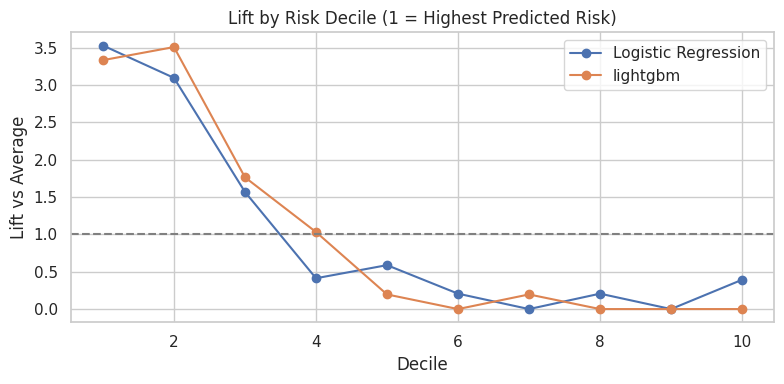

In [11]:
lift_lr = decile_lift_table(y_valid, proba_lr)
print('Logistic regression decile lift:')
display(lift_lr)

if proba_boost is not None:
    lift_boost = decile_lift_table(y_valid, proba_boost)
    print(f'{boost_model_name} decile lift:')
    display(lift_boost)

plt.figure(figsize=(8, 4))
plt.plot(lift_lr['decile'], lift_lr['lift_vs_avg'], marker='o', label='Logistic Regression')
if proba_boost is not None:
    plt.plot(lift_boost['decile'], lift_boost['lift_vs_avg'], marker='o', label=boost_model_name)
plt.axhline(1.0, linestyle='--', color='gray')
plt.title('Lift by Risk Decile (1 = Highest Predicted Risk)')
plt.xlabel('Decile')
plt.ylabel('Lift vs Average')
plt.legend()
plt.tight_layout()

## 7. Explainability

,importance
P_2_last,896
P_2_min,454
P_2_mean,402
D_43_last,171
D_44_mean,170
D_48_last,154
D_44_last,138
P_2_max,130
R_1_std,125
R_1_max,116


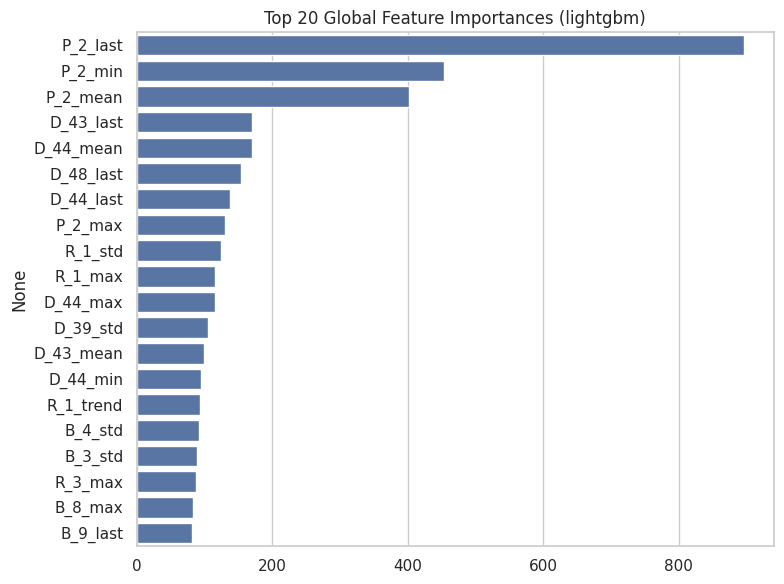

In [12]:
if boost_importance is not None:
    top_imp = boost_importance.sort_values(ascending=False).head(20)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_imp.values, y=top_imp.index, orient='h')
    plt.title(f'Top 20 Global Feature Importances ({boost_model_name})')
    plt.tight_layout()

    display(top_imp.to_frame('importance'))

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


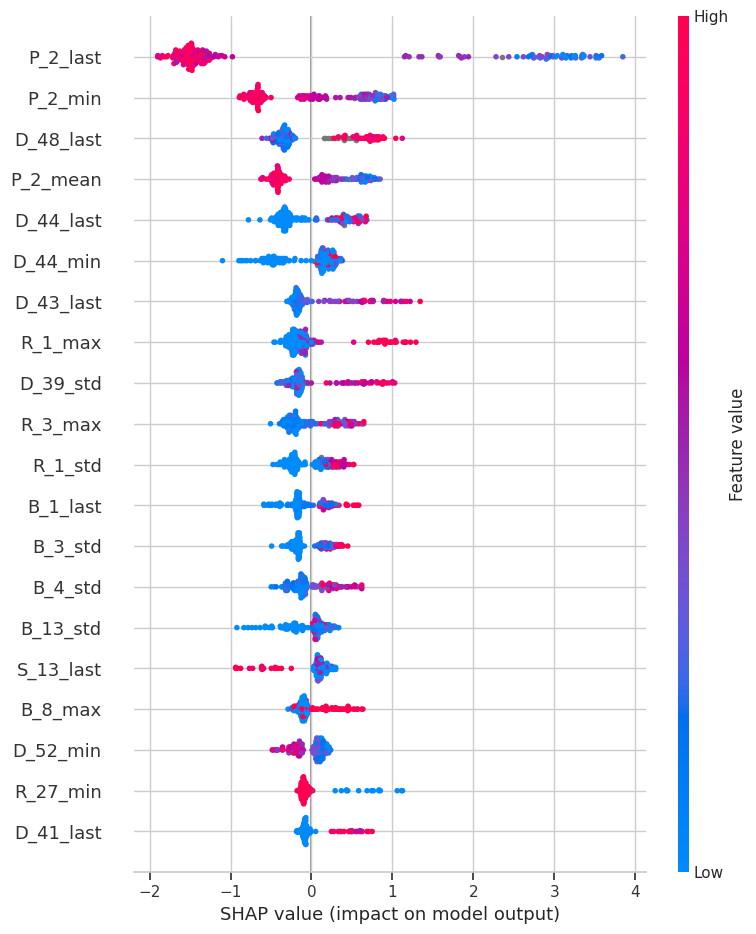

In [13]:
if HAS_SHAP and proba_boost is not None:
    shap_sample = X_valid.sample(n=min(2000, len(X_valid)), random_state=RANDOM_STATE).copy()

    if boost_model_name == 'lightgbm':
        for c in cat_cols:
            shap_sample[c] = shap_sample[c].astype('category')
        explainer = shap.TreeExplainer(gbm)
        shap_values = explainer.shap_values(shap_sample)
        shap.summary_plot(shap_values, shap_sample, show=True)

    elif boost_model_name == 'xgboost':
        shap_sample_enc = shap_sample.copy()
        for c in cat_cols:
            shap_sample_enc[c] = shap_sample_enc[c].astype('category').cat.codes
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(shap_sample_enc)
        shap.summary_plot(shap_values, shap_sample_enc, show=True)
else:
    print('SHAP skipped (missing package or boosted model).')

## 8. Segment-Level Behavior Insights

In [14]:
analysis_df = valid_df[['customer_ID', 'target']].copy()
analysis_df['score_lr'] = proba_lr
analysis_df['risk_decile_lr'] = pd.qcut(analysis_df['score_lr'].rank(method='first'), 10, labels=False) + 1
analysis_df['risk_decile_lr'] = 11 - analysis_df['risk_decile_lr']

key_behavior_cols = [
    c for c in valid_df.columns
    if c.endswith('_trend') or c.endswith('_std') or c.endswith('_missing_rate')
]
key_behavior_cols = key_behavior_cols[:12]

segment_view = valid_df[['customer_ID'] + key_behavior_cols].merge(
    analysis_df[['customer_ID', 'risk_decile_lr', 'target']],
    on='customer_ID', how='left'
)

segment_summary = (
    segment_view.groupby('risk_decile_lr')[key_behavior_cols + ['target']]
    .mean()
    .sort_index()
)

segment_summary.head(10)

,P_2_std,D_39_std,B_1_std,B_2_std,R_1_std,S_3_std,D_41_std,B_3_std,D_42_std,D_43_std,D_44_std,B_4_std,target
risk_decile_lr,,,,,,,,,,,,,
1,0.084887,0.428416,0.083782,0.217142,0.297277,0.107135,0.217437,0.130028,0.010121,0.129828,0.115366,0.074533,0.900000
2,0.081490,0.276631,0.077186,0.202182,0.269627,0.075783,0.128114,0.137208,0.041859,0.111915,0.105822,0.077797,0.789474
3,0.061339,0.140576,0.045858,0.136876,0.129164,0.081980,0.044384,0.058493,0.009959,0.061810,0.061293,0.051065,0.400000
4,0.048317,0.103276,0.031260,0.116035,0.105973,0.059571,0.025835,0.039999,0.003348,0.059029,0.059096,0.049920,0.105263
5,0.042876,0.116125,0.029564,0.110134,0.059862,0.045399,0.019547,0.024603,0.002306,0.053289,0.034287,0.046340,0.150000
6,0.043738,0.064208,0.016142,0.095166,0.038605,0.035524,0.007747,0.018396,0.007588,0.041877,0.013427,0.023568,0.052632
7,0.040252,0.107530,0.029148,0.082740,0.009609,0.031939,0.011715,0.015740,0.003948,0.073484,0.010890,0.033082,0.000000
8,0.032403,0.115457,0.017971,0.066909,0.007950,0.031282,0.006884,0.011133,0.005672,0.059753,0.014658,0.031102,0.052632
9,0.023615,0.083845,0.016621,0.073869,0.006268,0.053000,0.016733,0.009085,NaN,0.071518,0.005107,0.028790,0.000000


## 9. Interview Talking Points

- Why time-aware validation matters: random splits can leak future behavior into training; customer last-statement split is safer.
- Feature design: recency, volatility (`std`), directional trend (`trend`), and missingness patterns often carry default signals.
- Baseline progression: start linear for interpretability, then use gradient boosting to capture nonlinearity and interactions.
- Business usage: decile lift supports risk-tier policying (collections prioritization, credit line review, proactive outreach).
- Next improvements: target encoding with out-of-fold strategy, sequence models, and monotonic constraints for risk governance.

## 10. Load Test Data Only

Load test parquet once, then reuse `test_raw` in submission cells.


In [15]:
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/amex_data_parquet')
TEST_PATH = BASE_DIR / 'test_data.parquet'

if not TEST_PATH.exists():
    raise FileNotFoundError(f'Missing test file: {TEST_PATH}')

test_raw = pd.read_parquet(TEST_PATH)
test_raw['S_2'] = pd.to_datetime(test_raw['S_2'])

print('Loaded test_raw:', test_raw.shape)
test_raw.head(3)



Loaded test_raw: (11363762, 190)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,B_20,D_68,S_12,R_6,S_13,B_21,D_69,B_22,D_70,D_71,D_72,S_15,B_23,D_73,P_4,D_74,D_75,D_76,B_24,R_7,D_77,B_25,B_26,D_78,D_79,R_8,R_9,S_16,D_80,R_10,R_11,B_27,D_81,D_82,S_17,R_12,B_28,R_13,D_83,R_14,R_15,D_84,R_16,B_29,B_30,S_18,D_86,D_87,R_17,R_18,D_88,B_31,S_19,R_19,B_32,S_20,R_20,R_21,B_33,D_89,R_22,R_23,D_91,D_92,D_93,D_94,R_24,R_25,D_96,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,00000469ba478561f23a92a868bd366de6f6527a684c9a...,2019-02-19,0.631315,0.001912,0.010728,0.814497,0.007547,0.168651,0.009971,0.002347,0.113189,NaN,0.007584,0.116402,0.004483,0.009517,0.005178,NaN,0.474383,0.626467,NaN,0.174591,1.250677,1.003925,NaN,0.008718,0.001013,0.103590,0.119043,NaN,-0.002919,NaN,0.002771,0.004416,1.006875,1.005069,0.002810,0.105587,0.119198,0.321676,0.114564,NaN,NaN,0.003420,0.205898,NaN,0.010182,NaN,0.027472,0.588734,0.010489,1.881856,0.051811,CR,None,0.008294,0.008663,NaN,0.592103,0.009144,NaN,0.004986,NaN,0.190516,0.002675,0.409411,0.009990,NaN,0.005210,NaN,0.014684,0.004310,0.400602,1.134792,0.178862,0.959531,0.217694,0.20459,NaN,0.009799,0.007748,0.002916,0.006896,0.001656,0.004356,NaN,0.002008,NaN,0.002531,0.000348,0.001173,0.004170,0.004585,0.002291,0.508240,0.005093,1.002944,0.133804,0.004322,NaN,0.008857,0.004144,0.009563,0.006942,NaN,0.0,0.003684,0.009909,NaN,0.008908,0.002955,NaN,1,0.008999,0.003418,0.002200,0.003781,0.002948,0.004635,1.003810,0.006653,0.007474,0.000192,NaN,0.008761,0.000835,0.004389,0.004115,0.008442,0.009575,0.981078,0.134916,0.954664,0.971086,0.006562,0.002419,NaN,NaN,NaN,NaN,NaN,0.008146,0.007970,NaN,NaN,1.0,NaN,0.005124,NaN,NaN,NaN,1.004130,0.274203,0.004302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.006201,NaN,NaN,0.009664,NaN,NaN,NaN,NaN,0.007082,0.005957,NaN,NaN,NaN,NaN,NaN,NaN,0.004669,NaN,NaN,NaN,0.008281,NaN
1,00000469ba478561f23a92a868bd366de6f6527a684c9a...,2019-03-25,0.587042,0.005275,0.011026,0.810848,0.001817,0.241389,0.000166,0.009132,0.123035,NaN,0.006646,0.134878,0.009497,0.026313,0.009029,NaN,0.473587,0.611682,NaN,0.177115,0.234169,1.009301,NaN,0.003146,0.005533,0.101239,0.120991,NaN,0.031222,NaN,0.006497,0.010003,1.005728,1.000432,0.000525,0.160562,0.121490,0.170728,0.184116,NaN,0.028347,0.007156,0.403270,0.014491,0.025130,NaN,0.054790,0.622886,0.021704,2.043278,0.057567,CR,None,0.002011,0.000835,NaN,0.590922,0.000165,NaN,0.001557,NaN,0.190172,0.001771,0.561424,0.008125,NaN,0.008394,0.000606,0.011945,0.002283,0.605887,0.208381,0.179502,0.961667,0.216526,0.20657,NaN,0.004549,0.003098,NaN,0.003682,0.005516,0.001506,0.001013,0.006444,NaN,0.007169,0.003077,0.005880,0.004056,0.009634,0.001225,0.508681,0.007319,1.003831,0.144626,0.005300,NaN,0.001477,0.002083,0.002234,0.005523,NaN,0.0,0.006410,0.007458,NaN,0.000843,0.007457,NaN,1,0.005120,0.002382,0.006557,0.001691,0.004449,0.000574,1.004629,0.004394,0.001169,0.006693,NaN,0.004318,0.008072,0.007888,0.007656,0.006347,0.006952,0.966995,0.138531,0.957019,0.975003,0.004611,0.006549,0.003031,0.008755,NaN,NaN,0.004698,0.000078,0.015463,NaN,1.007666,1.0,NaN,0.000610,NaN,NaN,NaN,1.004495,0.353639,0.276623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.003833,0.008782,0.005579,0.007441,NaN,0.007598,0.008074,NaN,0.007188,0.001253,NaN,NaN,NaN,NaN,NaN,0.000142,0.004940,0.009021,NaN,0.003695,0.003753,0.001460
2,00000469ba478561f23a92a868bd366de6f6527a684c9a...,2019-04-25,0.609056,0.003326,0.016390,1.004620,0.000114,0.266976,0.004196,0.004192,0

## 11. Baseline Submission File

Generate baseline Kaggle submission using already-loaded `test_raw`.


In [16]:
def get_test_features_from_chunks(test_raw: pd.DataFrame) -> pd.DataFrame:
    if test_feature_path.exists() and not RETRAIN_FEATURES:
        test_features_local = pd.read_parquet(test_feature_path)
        print('Loaded cached test features:', test_features_local.shape)
        return test_features_local

    test_chunk_paths = build_feature_chunks_to_disk(
        test_raw,
        out_dir=test_chunk_dir,
        n_chunks=N_CHUNKS_TEST,
        max_trend_cols=TEST_MAX_TREND_COLS,
        prefix='test',
        retrain=RETRAIN_FEATURES,
    )

    test_features_local = load_feature_chunks(test_chunk_paths, desc='Loading test feature chunks')
    test_features_local.to_parquet(test_feature_path, index=False, compression='snappy')
    print('Built+saved test features:', test_features_local.shape)
    return test_features_local



In [ ]:
# Build test features and generate baseline_submission.csv
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/amex_data_parquet')
BASELINE_SUBMISSION_PATH = BASE_DIR / 'baseline_submission.csv'

if 'test_raw' not in globals():
    raise RuntimeError("test_raw not found. Run the 'Load Test Data Only' cell first.")

print('Building/loading chunked test features...')
test_features = get_test_features_from_chunks(test_raw)

for c in X_train.columns:
    if c not in test_features.columns:
        test_features[c] = np.nan
X_test = test_features[X_train.columns].copy()

# Score with best available baseline model
if proba_boost is not None and boost_model_name == 'lightgbm':
    X_test_boost = X_test.copy()
    for c in cat_cols:
        if c in X_test_boost.columns:
            X_test_boost[c] = X_test_boost[c].astype('category')
    baseline_pred = gbm.predict_proba(X_test_boost)[:, 1]
    baseline_model_used = 'lightgbm'

elif proba_boost is not None and boost_model_name == 'xgboost':
    X_test_enc = X_test.copy()
    for c in cat_cols:
        if c in X_test_enc.columns:
            train_categories = pd.Categorical(X_train[c]).categories
            X_test_enc[c] = pd.Categorical(X_test_enc[c], categories=train_categories).codes
    baseline_pred = xgb_model.predict_proba(X_test_enc)[:, 1]
    baseline_model_used = 'xgboost'

else:
    baseline_pred = logreg.predict_proba(X_test)[:, 1]
    baseline_model_used = 'logistic_regression'

baseline_submission = pd.DataFrame({
    'customer_ID': test_features['customer_ID'],
    'prediction': baseline_pred,
})
baseline_submission.to_csv(BASELINE_SUBMISSION_PATH, index=False)

print({'model_used': baseline_model_used, 'rows': len(baseline_submission), 'saved_to': str(BASELINE_SUBMISSION_PATH)})
baseline_submission.head()



Building/loading chunked test features...


Building test chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature engineering...
Using pandas feature enginee

Loading test feature chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Built+saved test features: (924621, 1153)


## 12. Advanced Flow: Time-Aware CV Ensemble + Stacking

Train a stronger ensemble using time-aware folds, then generate `advanced_submission.csv`.


In [ ]:
# Advanced model flow: time-aware CV with two boosted configs + meta logistic

N_FOLDS = 5
ADVANCED_SUBMISSION_PATH = BASE_DIR / 'advanced_submission.csv'

# Use full labeled customer-level table for advanced CV/fit
full_model_df = model_df.copy().reset_index(drop=True)
X_full = full_model_df.drop(columns=EXCLUDE_COLS)
y_full = full_model_df[TARGET_COL].astype(int)

adv_cat_cols = [
    c for c in X_full.columns
    if str(X_full[c].dtype) in ('object', 'category')
]

# Build contiguous time-aware folds by sorted last_statement_date
fold_ids = np.zeros(len(full_model_df), dtype=int)
fold_sizes = np.full(N_FOLDS, len(full_model_df) // N_FOLDS)
fold_sizes[:len(full_model_df) % N_FOLDS] += 1
start = 0
for f, sz in enumerate(fold_sizes):
    end = start + sz
    fold_ids[start:end] = f
    start = end


def build_lgb_params(config_name: str, use_gpu: bool = False) -> dict:
    if config_name == 'cfg_a':
        params = dict(
            n_estimators=900,
            learning_rate=0.03,
            num_leaves=96,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.75,
            objective='binary',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    else:
        params = dict(
            n_estimators=1200,
            learning_rate=0.02,
            num_leaves=128,
            min_child_samples=80,
            subsample=0.9,
            colsample_bytree=0.85,
            objective='binary',
            random_state=RANDOM_STATE + 7,
            n_jobs=-1,
        )
    if use_gpu:
        params['device'] = 'gpu'
    return params


def fit_predict_lgb(train_x, train_y, valid_x, params, cat_cols_local):
    xtr = train_x.copy()
    xva = valid_x.copy()
    for c in cat_cols_local:
        if c in xtr.columns:
            xtr[c] = xtr[c].astype('category')
            xva[c] = xva[c].astype('category')

    model = lgb.LGBMClassifier(**params)
    model.fit(xtr, train_y)
    pred = model.predict_proba(xva)[:, 1]
    return model, pred


if not HAS_LGBM:
    raise RuntimeError('Advanced flow currently requires LightGBM installed.')

oof_a = np.zeros(len(X_full), dtype=float)
oof_b = np.zeros(len(X_full), dtype=float)

for fold in range(N_FOLDS):
    valid_mask = fold_ids == fold
    train_mask = ~valid_mask

    X_tr = X_full.loc[train_mask]
    y_tr = y_full.loc[train_mask]
    X_va = X_full.loc[valid_mask]

    params_a = build_lgb_params('cfg_a', use_gpu=GPU_AVAILABLE)
    params_b = build_lgb_params('cfg_b', use_gpu=GPU_AVAILABLE)

    try:
        model_a, pred_a = fit_predict_lgb(X_tr, y_tr, X_va, params_a, adv_cat_cols)
    except Exception as e:
        if GPU_AVAILABLE:
            params_a.pop('device', None)
            model_a, pred_a = fit_predict_lgb(X_tr, y_tr, X_va, params_a, adv_cat_cols)
        else:
            raise

    try:
        model_b, pred_b = fit_predict_lgb(X_tr, y_tr, X_va, params_b, adv_cat_cols)
    except Exception as e:
        if GPU_AVAILABLE:
            params_b.pop('device', None)
            model_b, pred_b = fit_predict_lgb(X_tr, y_tr, X_va, params_b, adv_cat_cols)
        else:
            raise

    oof_a[valid_mask] = pred_a
    oof_b[valid_mask] = pred_b
    print(f'Fold {fold + 1}/{N_FOLDS} done.')

meta_X = pd.DataFrame({
    'pred_a': oof_a,
    'pred_b': oof_b,
    'pred_mean': 0.5 * (oof_a + oof_b),
})
meta_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
meta_model.fit(meta_X, y_full)
meta_oof_pred = meta_model.predict_proba(meta_X)[:, 1]

auc_adv = roc_auc_score(y_full, meta_oof_pred)
pr_auc_adv = average_precision_score(y_full, meta_oof_pred)
print({'advanced_meta_auc_oof': round(auc_adv, 5), 'advanced_meta_pr_auc_oof': round(pr_auc_adv, 5)})

# Refit base models on full labeled data
params_a_full = build_lgb_params('cfg_a', use_gpu=GPU_AVAILABLE)
params_b_full = build_lgb_params('cfg_b', use_gpu=GPU_AVAILABLE)

try:
    model_a_full, _ = fit_predict_lgb(X_full, y_full, X_full.iloc[:1], params_a_full, adv_cat_cols)
except Exception as e:
    if GPU_AVAILABLE:
        params_a_full.pop('device', None)
        model_a_full, _ = fit_predict_lgb(X_full, y_full, X_full.iloc[:1], params_a_full, adv_cat_cols)
    else:
        raise

try:
    model_b_full, _ = fit_predict_lgb(X_full, y_full, X_full.iloc[:1], params_b_full, adv_cat_cols)
except Exception as e:
    if GPU_AVAILABLE:
        params_b_full.pop('device', None)
        model_b_full, _ = fit_predict_lgb(X_full, y_full, X_full.iloc[:1], params_b_full, adv_cat_cols)
    else:
        raise

# Predict test
X_test_adv = X_test.copy()
for c in X_full.columns:
    if c not in X_test_adv.columns:
        X_test_adv[c] = np.nan
X_test_adv = X_test_adv[X_full.columns]

for c in adv_cat_cols:
    if c in X_test_adv.columns:
        X_test_adv[c] = X_test_adv[c].astype('category')

test_pred_a = model_a_full.predict_proba(X_test_adv)[:, 1]
test_pred_b = model_b_full.predict_proba(X_test_adv)[:, 1]

test_meta_X = pd.DataFrame({
    'pred_a': test_pred_a,
    'pred_b': test_pred_b,
    'pred_mean': 0.5 * (test_pred_a + test_pred_b),
})
advanced_pred = meta_model.predict_proba(test_meta_X)[:, 1]

advanced_submission = pd.DataFrame({
    'customer_ID': test_features['customer_ID'],
    'prediction': advanced_pred,
})
advanced_submission.to_csv(ADVANCED_SUBMISSION_PATH, index=False)

print({'rows': len(advanced_submission), 'saved_to': str(ADVANCED_SUBMISSION_PATH)})
advanced_submission.head()

